In [1]:
# Importera bibliotek
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

tf.keras.utils.set_random_seed(42)

# 1. Förstå datan

In [2]:
# Ladda in Fashion MNIST dataset
# https://keras.io/api/datasets/fashion_mnist/
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
# Undersöka vilken typ av data Fashion MNIST datasetet innehåller

# Kontrollera datatyp
print("Datatyp för träningsdata:", type(x_train))
print("Datatyp för träningslabels:", type(y_train))

# Kontrollera elementtypen
print("\nElementtyp för träningsdata:", x_train.dtype)
print("Elementtyp för träningslabels:", y_train.dtype)

# Visa shape för den första datapunkten
print("\nShape av den första datapunkten:")
print(x_train[0].shape)

# Visa den första datapunkten
print("\nFörsta datapunkten i x_train:")
print(x_train[0])

# Kontrollera min/max värdena
print("\nMinsta värde i träningsdata:", x_train.min())
print("Största värde i träningsdata:", x_train.max())

Datatyp för träningsdata: <class 'numpy.ndarray'>
Datatyp för träningslabels: <class 'numpy.ndarray'>

Elementtyp för träningsdata: uint8
Elementtyp för träningslabels: uint8

Shape av den första datapunkten:
(28, 28)

Första datapunkten i x_train:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0

In [4]:
# Storlek och struktur på träningsdata och testdata

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Undersökning av datasetet

Datasetet innehåller 'numpy.ndarray' (NumPy arrayer) med numeriska värden (uint8).  

Datatypen *uint8* visar att datan består av heltal mellan 0 och 255.  

När vi undersöker den första datapunkten i träningsdatan (x_train) ser vi att den representeras som en matris (med numeriska värden) med storleken 28x28. 

Det minsta värdet är 0 och det största är 255.    

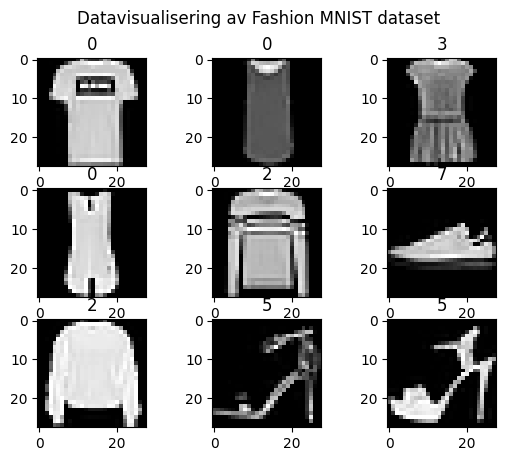

In [5]:
# Datavisualisering av Fashion MNIST datasetet

plt.suptitle("Datavisualisering av Fashion MNIST dataset")

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])

plt.show()

## Visualisering av datasetet

Ovanför visas 9 datapunkter från Fashion MNIST datasetet.

Genom visualiseringen kan vi se att datan representerar grayscale-bilder med storleken 28x28 pixlar.

## Datasetets struktur

Fashion MNIST datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder

Varje bild har storleken 28x28 pixlar och är i grayscale-format.

In [6]:
# Visa vilka klasser som finns i datasetet

print("Unika klasser:", np.unique(y_train))

Unika klasser: [0 1 2 3 4 5 6 7 8 9]


## Klassfördelning

Datasetet innehåller 10 olika klasser representerade av siffrorna 0–9.

Varje klass motsvarar en viss typ av klädesplagg.   

In [7]:
# Kontrollera klassfördelning

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Klass {label}: {count} bilder")

Klass 0: 6000 bilder
Klass 1: 6000 bilder
Klass 2: 6000 bilder
Klass 3: 6000 bilder
Klass 4: 6000 bilder
Klass 5: 6000 bilder
Klass 6: 6000 bilder
Klass 7: 6000 bilder
Klass 8: 6000 bilder
Klass 9: 6000 bilder


Alla klasser innehåller 6000 bilder, vilket betyder att datasetet är balanserat och inte innehåller några tydliga obalanser mellan klasserna.


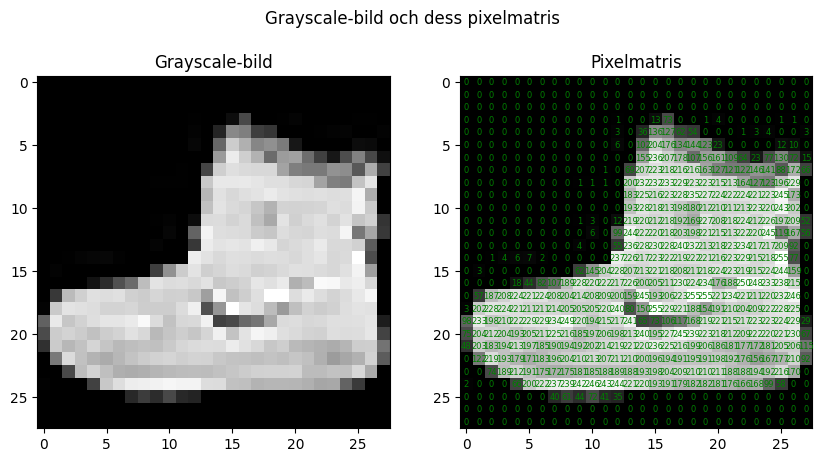

In [8]:
# Visa en grayscale-bild och dess pixelmatris
plt.figure(figsize=(10,5))
plt.suptitle("Grayscale-bild och dess pixelmatris")

# Visa grayscale-bilde
plt.subplot(1,2,1)
plt.imshow(x_train[0], cmap="gray")
plt.title("Grayscale-bild")

# Visa pixelvärden som matris
plt.subplot(1,2,2)
plt.imshow(x_train[0], cmap="gray")
plt.title("Pixelmatris")

# i = row, j = column; 28 rows, 28 columns
for i in range(28):
    for j in range(28):
        plt.text(j, i, x_train[0][i, j],
                 ha="center", va="center", fontsize=6, color="green")

plt.show()

Visualiseringen hjälper oss att förstå hur bilddata representeras som numeriska matriser i deep learning.

## Sammanfattning av datasetet
#### Input-data för deep learning

Fashion MNIST innehåller grayscale-bilder med storleken 28x28 pixlar.  

*x_train* och *x_test* innehåller bilderna, medan *y_train* och *y_test* innehåller klasser för varje bild.

Bilderna representeras som numeriska matriser där varje värde motsvarar intensiteten hos en pixel i bilden, där pixelvärden varierar från 0 (svart) till 255 (vitt).  

Eftersom bilderna är i grayscale-format representeras de i två dimensioner (28x28).  

Färgbilder skulle istället innehålla tre kanaler (RGB) och representeras som tredimensionella matriser.   

# 2. Förbereda datan

## Preprocessing av data

I denna del förbereds datasetet för deep learning modeller genom olika preprocessing-metoder.  

Vi kommer att testa och jämföra olika tekniker som normalisering, standardisering och reshaping av input data.  

### 2.1. Normalisering av data

Pixelvärden i Fashion MNIST varierar mellan 0 och 255.  

För att göra träningen av deep learning modeller mer stabil och effektiv normaliseras datan genom att dividera alla pixelvärden med 255.  

Efter normalisering varierar värdena mellan 0 och 1 istället för mellan 0 och 255.

Detta hjälper deep learning modeller att träna snabbare och mer stabilt eftersom stora tal kan göra träningen svårare.  

In [9]:
# Normalisering av data

# Normalisering träningsdata och testdata
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

# Kontrollera minsta och största värden efter normalisering
print("Minsta värde efter normalisering:", x_train_normalized.min())
print("Största värde efter normalisering:", x_train_normalized.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


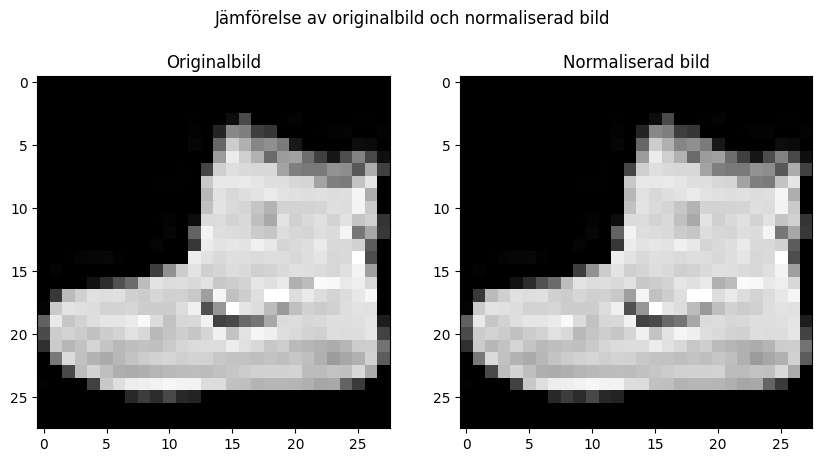

In [10]:
# Jämför originalbild och normaliserad bild
plt.figure(figsize=(10,5))
plt.suptitle("Jämförelse av originalbild och normaliserad bild")

# Originalbild
plt.subplot(1,2,1)
plt.imshow(x_train[0], cmap="gray")
plt.title("Originalbild")

# Normaliserad bild
plt.subplot(1,2,2)
plt.imshow(x_train_normalized[0], cmap="gray")
plt.title("Normaliserad bild")

plt.show()

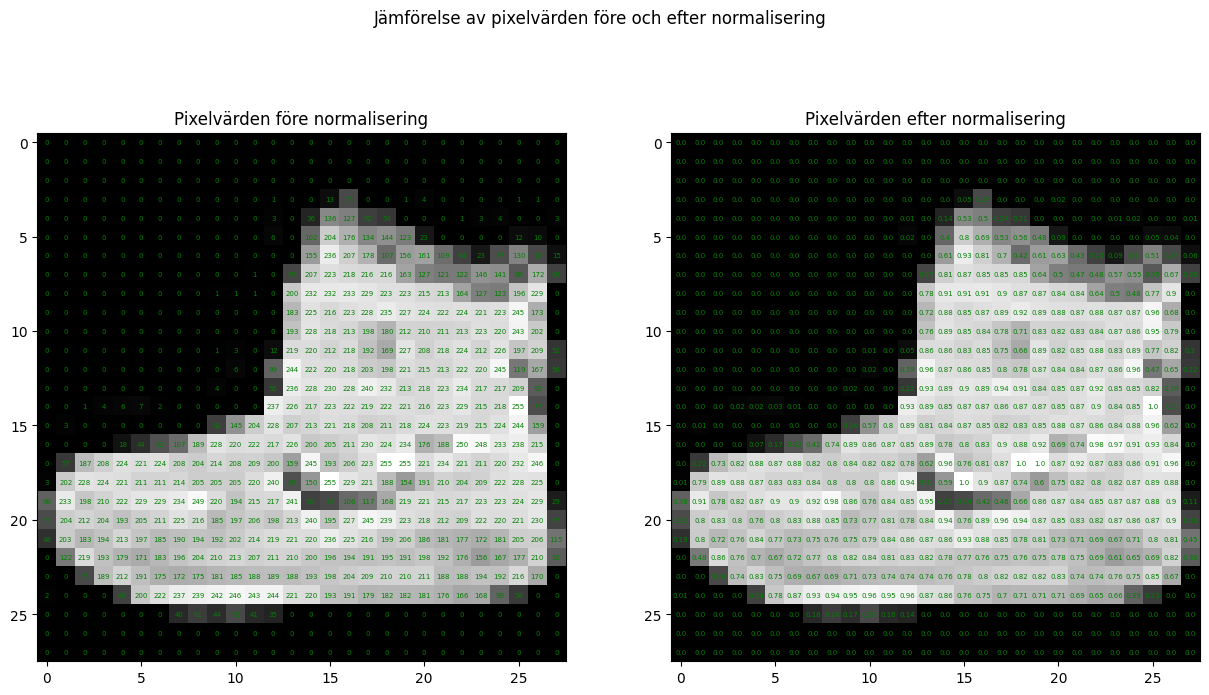

In [11]:
# Jämför pixelvärden före och efter normalisering
plt.figure(figsize=(15,8))
plt.suptitle("Jämförelse av pixelvärden före och efter normalisering")

# Före normalisering
plt.subplot(1,2,1)
plt.imshow(x_train[0], cmap="gray")
plt.title("Pixelvärden före normalisering")

for i in range(28):
    for j in range(28):
        plt.text(j, i,
                 x_train[0][i, j],
                 ha="center",
                 va="center",
                 fontsize=5,
                 color="green")


# Efter normalisering
plt.subplot(1,2,2)
plt.imshow(x_train_normalized[0], cmap="gray")
plt.title("Pixelvärden efter normalisering")

for i in range(28):
    for j in range(28):
        plt.text(j, i,
                 round(x_train_normalized[0][i, j], 2),
                 ha="center",
                 va="center",
                 fontsize=5,
                 color="green")


plt.show()

## Visualisering av normalisering

Ovanför jämförs en originalbild med en normaliserad bild samt pixelvärden före och efter normalisering.  

Originalbilden och den normaliserade bilden ser visuellt identiska ut.  

Det beror på att normalisering förändrar pixelvärdenas men inte bildens struktur eller innehåll.  

Genom att jämföra pixelvärdena före och efter normalisering kan vi se att pixelvärdena förändras från intervallet 0–255 till 0–1.  

### 2.2. Standardisering av data
 
En annan preprocessing metod är standardisering.   

Vid standardisering centreras datan kring medelvärdet och skalas med hjälp av standardavvikelsen, detta görs med formeln: (x - mean) / std.  

Detta kan hjälpa deep learning modeller att träna mer stabilt och effektivt, särskilt när datan innehåller stora variationer i pixelvärden.

In [12]:
# Medelvärde och standardavvikelse
mean = np.mean(x_train)
std = np.std(x_train)

print("Medelvärde och standardavvikelse:")
print("Medelvärde:", mean)
print("Standardavvikelse:", std)

Medelvärde och standardavvikelse:
Medelvärde: 72.94035223214286
Standardavvikelse: 90.02118235130526


In [13]:
# Standardisera träningsdata och testdata
x_train_standardized = (x_train - mean) / std
x_test_standardized = (x_test - mean) / std

# Kontrollera minsta och största värden efter standardisering
print("Minsta och största värden efter standardisering:")
print("Minsta värde:", x_train_standardized.min())
print("Största värde:", x_train_standardized.max())

print("\nMedelvärde efter standardisering:", round(x_train_standardized.mean(), 2))
print("Standardavvikelse efter standardisering:", round(x_train_standardized.std(), 2))

Minsta och största värden efter standardisering:
Minsta värde: -0.8102576563313186
Största värde: 2.022408982114612

Medelvärde efter standardisering: 0.0
Standardavvikelse efter standardisering: 1.0


Efter centreras pixelvärdena kring medelvärdet, vilket innebär att värdena kan bli både negativa och positiva.   

Efter standardisering blev medelvärdet ungefär 0 och standardavvikelsen ungefär 1.

Detta gör att datan får en mer balanserad fördelning för modellen.  

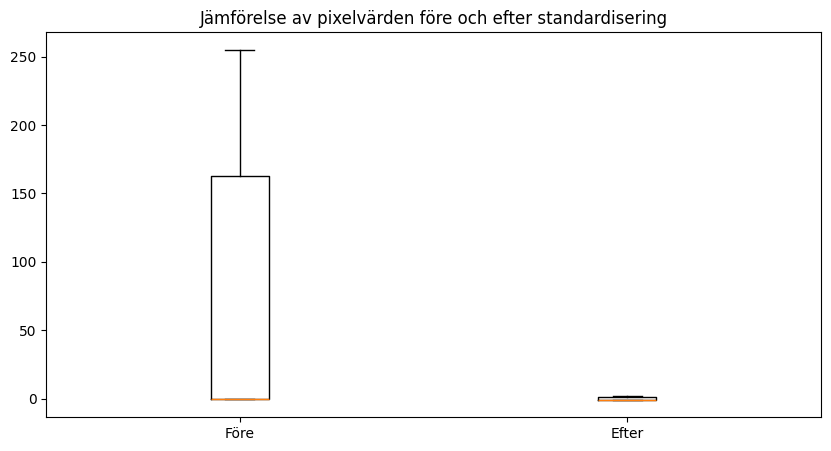

In [19]:
# Jämför pixelvärden före och efter standardisering
plt.figure(figsize=(10,5))

plt.boxplot([
    x_train.flatten(),
    x_train_standardized.flatten()
],
tick_labels = ["Före", "Efter"])

plt.title("Jämförelse av pixelvärden före och efter standardisering")

plt.show()

Boxploten visar att pixelvärdenas skala förändras efter standardisering.   

Före standardisering varierade värdena mellan 0 och 255, medan värdena efter standardisering blev mer centrerade och mindre spridda.   

Detta kan hjälpa modellen att träna mer stabilt och effektivt.   

### 2.3. Reshaping av data

Olika deep learning modeller kräver olika input format.

Dense/DNN modeller arbetar med flattenade vektorer där alla neuroner är kopplade till varandra (fully connected).

CNN modeller är däremot speciellt utvecklade för bilddata och kan bättre analysera relationer mellan närliggande pixlar i en bild.

Därför behöver datan reshapas beroende på vilken modell som används.

#### Flatten för Dense/DNN modeller

För Dense/DNN modeller flattenas bilderna från formatet (28,28) till (784,).   

Detta görs eftersom Dense/DNN modeller arbetar med endimensionella vektorer istället för tvådimensionella bildmatriser.   

Talet 784 kommer från bildens storlek: 28 × 28 = 784 pixlar.   

In [15]:
# Reshape data för Dense/DNN modeller
x_train_flatten = x_train_normalized.reshape(x_train.shape[0], -1)
x_test_flatten = x_test_normalized.reshape(x_test.shape[0], -1)

# Kontrollera shape efter flattening
print("Shape efter flattening:", x_train_flatten.shape)

Shape efter flattening: (60000, 784)


Shape *(60000, 784)* betyder att datasetet innehåller 60 000 bilder där varje bild representeras som en vektor med 784 pixelvärden.

Efter flattening representeras varje bild som en endimensionell vektor istället för en 28x28 matris.

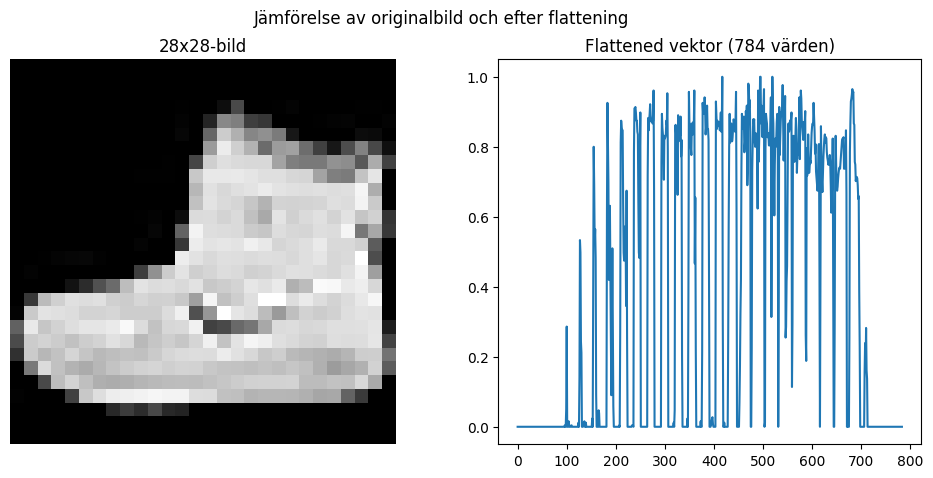

In [16]:
# Visualisera flattening av en bild
plt.figure(figsize=(12,5))
plt.suptitle("Jämförelse av originalbild och efter flattening")

# Originalbild
plt.subplot(1,2,1)
plt.imshow(x_train[0], cmap="gray")
plt.title("28x28-bild")
plt.axis("off")

# Flattened vektor
plt.subplot(1,2,2)
plt.plot(x_train_flatten[0])
plt.title("Flattened vektor (784 värden)")

plt.show()

#### Visualisering av flattening

Ovanför visas hur en bild omvandlas från en tvådimensionell matris till en endimensionell vektor.

#### CNN input

CNN modeller arbetar direkt med bildens spatiala struktur och behöver därför ett tredimensionellt input format.

Därför läggs en extra dimension till för färgkanalen.

In [17]:
# Reshape data för CNN-modeller
x_train_cnn = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_normalized.reshape(-1, 28, 28, 1)

# Kontrollera shape för CNN-input
print("Shape för CNN-input:", x_train_cnn.shape)

Shape för CNN-input: (60000, 28, 28, 1)


Shape *(60000, 28, 28, 1)* betyder att datasetet innehåller 60 000 bilder med storleken 28x28 och en färgkanal (grayscale).

CNN modeller kräver ett tredimensionellt input format där bilderna representeras med höjd, bredd och antal kanaler.

Eftersom Fashion MNIST består av grayscale-bilder används endast en kanal, vilket ger formatet (28,28,1).

In [18]:
# Kontrollera shape för CNN-input
print("Shape för hela datasetet:")
print(x_train_cnn.shape)

print("\nShape för en bild:")
print(x_train_cnn[0].shape)

Shape för hela datasetet:
(60000, 28, 28, 1)

Shape för en bild:
(28, 28, 1)


CNN input innehåller en extra dimension för färgkanalen.

Shape (28,28,1) betyder att bilden har:

- 28 pixlar i höjd
- 28 pixlar i bredd
- 1 gkanal (grayscale)

För grayscale-bilder används en kanal eftersom varje pixel endast innehåller ett ljusintensitetsvärde.

Färgbilder i RGB-format skulle istället ha tre kanaler:

- R = Red
- G = Green
- B = Blue

Då skulle input formatet exempelvis vara (28,28,3).

#### Jämförelse mellan input-format

Dense/DNN modeller använder flattenade vektorer medan CNN modeller arbetar direkt med bildens tvådimensionella struktur.

CNN modeller kan därför bättre bevara spatiala relationer mellan olika delar av bilden.

### 2.4. Jämförelse av preprocessing-metoder

Olika preprocessing metoder förändrar hur datan representeras för deep learning modeller.

Normalisering skalar pixelvärden mellan 0 och 1, medan standardisering centrerar värdena kring medelvärdet.

Flattening omvandlar bilder till endimensionella vektorer för Dense/DNN modeller, medan CNN modeller arbetar direkt med bildens tvådimensionella struktur och en extra kanal för grayscale formatet.

## Sammanfattning av preprocessing

Preprocessing förändrar hur datan representeras och förbereds för olika deep learning modeller.

Normalisering och standardisering förändrar pixelvärdenas intervall, medan reshaping anpassar datans format beroende på modelltyp.

Dense/DNN modeller använder flattenade vektorer medan CNN modeller arbetar direkt med bildens struktur.